# <u>Simple Linear Regression (one feature)</u>

## Topics

* [1. Basic Concept of Machine Learning](#basics)
* [2. Data Representation](#data)
* [3. Data types](#types)
* [4. Encoding for categorical data](#code)
* [5. Types of ML Tasks](#tasks)
* [6. Model and Parameters](#model)
* [7. Learner](#learn)
* [8. Loss Function](#loss)
* [9. Risk (Model Error)](#risk)
* [10. Empirical Risk Minimization (ERM)](#erm)
* [11. Optimization (Gradient Descent)](#optim)
* [12. Learner summary](#summary)
* [13. Components of Supervised Learning](#com)


In [17]:
from sklearn.datasets import load_iris # iris dataset
import pandas as pd # for pandas dataframe
import numpy as np 
import matplotlib.pyplot as plt # for plotting
from sklearn.preprocessing import OrdinalEncoder # for ordinal encoding categorical variables

<a class="anchor" id="basics"></a>
## 1. Basic Concept of Machine Learning

Machine learning is defined as:

**A program learns from experience (E) for a task (T) with performance measure (P) if performance improves with experience.**

Example:

| Component       | Example             |
| --------------- | ------------------- |
| Experience (E)  | Training data       |
| Task (T)        | Predict house price |
| Performance (P) | Prediction error    |

Example dataset:

| size | rooms | price  |
| ---- | ----- | ------ |
| 120  | 3     | 300000 |
| 80   | 2     | 200000 |



<a class="anchor" id="data"></a>
## 2. Data Representation

In supervised learning, the dataset is:

$$
\mathcal{D} = \left( \left(x^{(1)},y^{(1)}\right), ..., \left(x^{(n)},y^{(n)}\right) \right) \in (\mathcal{X} \times \mathcal{Y})^n
$$

Notation:

- $\mathcal{X} \rightarrow$ input space, usually $\mathcal{X} \subset \mathbb{R}^p$ 

- $\mathcal{Y} \rightarrow$ target space

- $\left(x^{(1)},y^{(1)}\right) \in \mathcal{X} \times \mathcal{Y} \rightarrow$ i-th obseration

- $x_j = \left( x_j^{(1)}, ..., x_j^{(n)} \right)  \rightarrow$ j-th feature vector

- $(\mathcal{X} \times \mathcal{Y})^n \rightarrow$ set of all datasets of size $n$ denoted as $\mathbb{D}_n$

- $\bigcup_{n\in \mathbb{N}} (\mathcal{X} \times \mathcal{Y})^n \rightarrow$ set of all finite datasets of size $n$ denoted as $\mathbb{D}$

- $p \rightarrow$ number of features

- $y \rightarrow$ target value

- $n \rightarrow$ number of observations


In [6]:
iris = load_iris()
X = iris.data
print("Features:\n",X[:3,:])
y = iris.target
print("Targtes encoded as numbers:\n",y) 

print("Iris data has 150 observations of 4 features:",X.shape)
print("Feature names of iris data:",iris.feature_names)
print("Unique Target names of iris_data:",iris.target_names,"\n")
#print("Target names of iris_data:",iris.target_names[y],"\n")

iris_data = pd.DataFrame(
    {
    "Sepal Length": X[:,0],
    "Sepal Width": X[:,1],
    "Petal Length": X[:,2],
    "Petal Width": X[:,3],
    "Species": iris.target_names[y]
    },index=None)

setosa = iris_data[iris_data["Species"] == "setosa"]
#print(setosa.head(),"\n")

print("Iris data\n",iris_data.iloc[[0,13,25,117,81,149],:],"\n")
print(f"D = (({X[0,:]},{iris.target_names[y][0]}), ..., ({X[-1,:]},{iris.target_names[y][-1]}) )")


Features:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]]
Targtes encoded as numbers:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Iris data has 150 observations of 4 features: (150, 4)
Feature names of iris data: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Unique Target names of iris_data: ['setosa' 'versicolor' 'virginica'] 

Iris data
      Sepal Length  Sepal Width  Petal Length  Petal Width     Species
0             5.1          3.5           1.4          0.2      setosa
13            4.3          3.0           1.1          0.1      setosa
25            5.0          3.0           1.6          0.2      setosa
117           7.7          3.8           6.7          2.2   virgini

<a class="anchor" id="types"></a>
## 3. Data types

**Case 1: Numerical features $\in \mathbb{R}$ & numerical targets $\in \mathbb{R}$** $\Rightarrow$ Regression 
- Example: $\left((18, 170),28\right) \in \mathcal{X} \times \mathcal{Y}$ 
with $\mathcal{X}=(\text{age}, \text{height\_cm}) \subset \mathbb{R}^2$ and $\mathcal{Y} = \text{bmi}$


**Case 2: Numerical features $\in \mathbb{R}$ & integer targets $\in \mathbb{Z}$ as numeric values** $\Rightarrow$ Regression
- Example: $\left((450, 50000),436\right) \in \mathcal{X} \times \mathcal{Y}$ 
with $\mathcal{X}=(\text{store\_size\_sq}, \text{budget}) \subset \mathbb{R}^2$ and $\mathcal{Y} = \text{num\_customers}$

**Case 3: Numerical features $\in \mathbb{R}$ & integer targets $\in \mathbb{Z}$ as labels** $\Rightarrow$ Classification
- Example: $\left((13, 42,25),0\right) \in \mathcal{X} \times \mathcal{Y}$ 
with $\mathcal{X}=(\text{weight\_kg}, \text{height\_cm},\text{length\_cm}) \subset \mathbb{R}^3$ and $\mathcal{Y} = {\{ \underbrace{0}_{\text{cat}},\underbrace{1}_{\text{dog}},\underbrace{2}_{\text{rabbit}}\}}$

**Case 4: Numerical features $\in \mathbb{R}$ & categorical targets $\in \{C_1,...,C_g\}$** $\Rightarrow$ Classification
- Example: $\left((1.2,150),\text{car}\right) \in \mathcal{X} \times \mathcal{Y}$ 
with $\mathcal{X}=(\text{weight\_tons}, \text{horse\_power}) \subset \mathbb{R}^2$ and $\mathcal{Y} = {\{\text{car},\text{truck},\text{motorcycle}\}}$

**Case 5: Numerical features $\in \mathbb{R}$ & binary targets $\in \{0,1\}$** $\Rightarrow$ Classification
- Example: $\left((115000,700),1\right) \in \mathcal{X} \times \mathcal{Y}$ 
with $\mathcal{X}=(\text{income\_dollar}, \text{credit\_score}) \subset \mathbb{R}^2$ and $\mathcal{Y} = \{\underbrace{0}_{\text{rejected}},\underbrace{1}_{\text{approved}}\}$

**Problem:** Most ML models can only deal with numerical features (altough Decision trees accept categorical features)

**Solution:** <u>Encode</u> categorical features


<a class="anchor" id="code"></a>
## 4. Encoding for categorical data

**Problem:** Most ML models expect numerical features.

**Solution:** Encode categorical features.

**Idea:** If a variable $x$ has $k$ possible categories, we replace it with a vector of length $k$ with at most one element being 1, and 0 otherwise.

$$
o(x)_j = \mathbb{I}(x  = j) \in \{0,1\} \hspace{1mm} \text{ one entry of } \hspace{1mm}  o(x) \in \{0,1\}^k
$$

- Each entry of $o(x)$ is treated as a separate feature
- $j$ is one of the $k$ possible categories of $x$
- Equivalent notation: $o(x)_j = \begin{cases} 1 \text{ , if }x=j \\ 0 \text{ ,otherwise}  \end{cases}$

<div style="display:flex; gap:20px;">

<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>One-hot encoding (k dummies)</u></h5>

- nominal categories
- $k$ dummies with ``exactly one`` element being 1 ("hot")

Example:

| country | city   | size $m^2$ | price  |
| ------- | ------ | --------- | ------ |
| Germany | Berlin | 70        | 500000 |
| Germany | Munich | 80        | 650000 |
| France  | Paris  | 60        | 700000 |
| France  | Lyon   | 75        | 450000 |

The **problem** is that **country** and **city** are **categorical** and most ML models cannot use them directly.

country $\Rightarrow$ Possible values are {Germany,France}

| Germany | France |
| ------- | ------ |
| 1       | 0      |
| 1       | 0      |
| 0       | 1      |
| 0       | 1      |


city $\Rightarrow$ Possible values are {Berlin,Munich,Paris,Lyon}

| Berlin | Munich | Paris | Lyon |
| ------ | ------ | ----- | ---- |
| 1      | 0      | 0     | 0    |
| 0      | 1      | 0     | 0    |
| 0      | 0      | 1     | 0    |
| 0      | 0      | 0     | 1    |


Final dataset after encoding $\Rightarrow$ combine encoded columns with the numerical feature:

| Germany | $\color{red}\text{France}$ | $\color{orange}\text{Berlin}$ | $\color{yellow}\text{Munich}$ | Paris | Lyon | size | price  |
| ------- | ------ | ------ | ------ | ----- | ---- | ---- | ------ |
| $\color{green}1$       | $\color{green}0$      | 1      | 0      | 0     | 0    | 70   | 500000 |
| 1       | 0      | 0      | 1      | 0     | 0    | 80   | 650000 |
| 0       | 1      | 0      | 0      | 1     | 0    | 60   | 700000 |
| 0       | 1      | 0      | 0      | 0     | 1    | 75   | 450000 |


Total number of new columns: $\text{number\_categories(country)}$ + $\text{number\_categories(city)}$

<u>Problem with one-hot encoding</u>

- One-hot encoding contains redundancy.
    - Because if we know two entries, the third is determined.


- Columns are linear dependent since $\sum_{j=1}^k o(x)_j = 1$
    - i.e. row 1: $\sum_{j \in \{\text{Germany},\text{France}\}}^k o(\text{country})_j = \color{green}1 + \color{green}0\color{white}=1$
    - i.e. column vector Germany $(1,1,0,0) = 0\cdot\color{red}(0,0,1,1)\color{white} + 1\cdot\color{orange}(1,0,0,0)\color{white} + 1\cdot\color{yellow}(0,1,0,0)\color{white} + 0\cdot((0,0,1,0)+(0,0,0,1))$
    - relationships such as these between columns (called **multicollinearity**) are **bad** since in many models we express dataframes in matrices (called Design matrix) and some analytical equations for Machine Learning do not work on matrices with linear dependent columns (i.e. in linear regression) 

<u>Solution: Dummy encoding</u>

</div>




<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Dummy encoding (k-1 dummies)</u></h5>

- nominal categories
- $k-1$ dummies with ``at most one`` element being 1 ("hot")
- remove one column per feature to avoid redundancy

country (reference = France)

| Germany |
| ------- |
| 1       |
| 1       |
| 0       |
| 0       |

country $\in$ {Germany, France} $\mapsto$ $o(x)=(\text{country}_\text{Germany})$ for reference category France with $\text{country}_\text{Germany}=0$ and $o(x)=(0)$ for country=France


city (reference = Lyon)

| Berlin | Munich | Paris |
| ------ | ------ | ----- |
| 1      | 0      | 0     |
| 0      | 1      | 0     |
| 0      | 0      | 1     |
| 0      | 0      | 0     |

city $\in$ {Berlin, Munich, Paris,Lyon} $\mapsto$ $o(x)=(\text{city}_\text{Berlin},\text{city}_\text{Munich},\text{city}_\text{Paris})$ for reference category Lyon with $\text{city}_\text{Berlin}=\text{city}_\text{Munich}=\text{city}_\text{Paris}=0$ and $o(x)=(0,0,0)$ for cityy=Lyon


Final encoded dataset

| Germany | Berlin | Munich | Paris | size | price  |
| ------- | ------ | ------ | ----- | ---- | ------ |
| 1       | 1      | 0      | 0     | 70   | 500000 |
| 1       | 0      | 1      | 0     | 80   | 650000 |
| 0       | 0      | 0      | 1     | 60   | 700000 |
| 0       | 0      | 0      | 0     | 75   | 450000 |

**Note: To obtain a full-rank design matrix we typically require that the number of features is less than the number of observations $(p \le n)$ or in other words the number of columns is less than the number of rows. Dummy encoding removes the deterministic linear dependence introduced by one-hot encoding, but additional dependencies may still occur if the dataset is small or features are correlated.**


</div>

</div>


<div style="display:flex; gap:20px;">

<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


<h5 style="text-align:center;"><u>One-hot encoding for categorical targets</u></h5>

Since the target variable can also be categorical (Classification task) we can encode it.

Example:

| Image  | Label |
| ------ | ----- |
| image1 | cat   |
| image2 | dog   |


Encode target as

| cat | dog |
| --- | --- |
| 1   | 0   |
| 0   | 1   |

This is common in neural networks.

</div>


<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">
<h5 style="text-align:center;"><u>Ordinal encoding</u></h5>

Some categories have natural order.

Example:

| Education level |
| --------------- |
| high school     |
| bachelor        |
| master          |
| PhD             |


Here we can encode them as

| Category    | Encoding |
| ----------- | -------- |
| high school | 1        |
| bachelor    | 2        |
| master      | 3        |
| PhD         | 4        |

This preserves the ordering information.



</div>

</div>

```python

import pandas as pd

pd.get_dummies(df, columns) # one-hot encoding of dataframe df for specific columns

pd.get_dummies(df, columns,drop_first=True) # dummy encoding of dataframe df for specific columns

from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

df[["col1", "col2"]] = encoder.fit_transform(df[["col1", "col2"]]) # ordinal encoding of chosen columns

```

| Encoding | Library method                 | Manual idea         |
| -------- | ------------------------------ | ------------------- |
| One-hot  | `pd.get_dummies()`             | boolean comparisons |
| Dummy    | `get_dummies(drop_first=True)` | omit one category   |
| Ordinal  | `OrdinalEncoder()`             | mapping dictionary  |


In [ ]:
df = pd.DataFrame({
    "country": ["Germany", "Germany", "France", "France"],
    "city": ["Berlin", "Munich", "Paris", "Lyon"],
    "size": [70, 80, 60, 75],
    "price": [500000, 650000, 700000, 450000]
})

print(f"{df}\n")

df_onehot = pd.get_dummies(df, columns=["country", "city"])

print(f"One-hot encoding:\n{df_onehot}\n")

df_manual = df.copy()


df_manual["Germany"] = (df["country"] == "Germany").astype(int)
df_manual["France"] = (df["country"] == "France").astype(int)

df_manual["Berlin"] = (df["city"] == "Berlin").astype(int)
df_manual["Munich"] = (df["city"] == "Munich").astype(int)
df_manual["Paris"] = (df["city"] == "Paris").astype(int)
df_manual["Lyon"] = (df["city"] == "Lyon").astype(int)

print(f"One-hot encoding manually:\n{df_manual}\n")



df_dummy = pd.get_dummies(df, columns=["country", "city"], drop_first=True)

print(f"Dummy encoding:\n{df_dummy}\n")



df_dummy_manual = df.copy()

df_dummy_manual["Germany"] = (df["country"] == "Germany").astype(int)

df_dummy_manual["Berlin"] = (df["city"] == "Berlin").astype(int)
df_dummy_manual["Munich"] = (df["city"] == "Munich").astype(int)
df_dummy_manual["Paris"] = (df["city"] == "Paris").astype(int)

print(f"Dummy encoding manually:\n{df_dummy_manual}\n")


   country    city  size   price
0  Germany  Berlin    70  500000
1  Germany  Munich    80  650000
2   France   Paris    60  700000
3   France    Lyon    75  450000

One-hot encoding:
   size   price  country_France  country_Germany  city_Berlin  city_Lyon  \
0    70  500000           False             True         True      False   
1    80  650000           False             True        False      False   
2    60  700000            True            False        False      False   
3    75  450000            True            False        False       True   

   city_Munich  city_Paris  
0        False       False  
1         True       False  
2        False        True  
3        False       False  

One-hot encoding manually:
   country    city  size   price  Germany  France  Berlin  Munich  Paris  Lyon
0  Germany  Berlin    70  500000        1       0       1       0      0     0
1  Germany  Munich    80  650000        1       0       0       1      0     0
2   France   Paris    60 

In [21]:
print(f"{df}\n")

encoder = OrdinalEncoder()

df_ordinal = df.copy()

df_ordinal[["country", "city"]] = encoder.fit_transform(df[["country", "city"]])

print(df_ordinal,"\n")


df_education = pd.DataFrame({
    "education": ["high school", "bachelor", "master", "PhD","high school"]
})

mapping = {
    "high school": 1,
    "bachelor": 2,
    "master": 3,
    "PhD": 4
}

df_education["education_encoded"] = df_education["education"].map(mapping)

print(df_education)

   country    city  size   price
0  Germany  Berlin    70  500000
1  Germany  Munich    80  650000
2   France   Paris    60  700000
3   France    Lyon    75  450000

   country  city  size   price
0      1.0   0.0    70  500000
1      1.0   2.0    80  650000
2      0.0   3.0    60  700000
3      0.0   1.0    75  450000 

     education  education_encoded
0  high school                  1
1     bachelor                  2
2       master                  3
3          PhD                  4
4  high school                  1


<a class="anchor" id="tasks"></a>
## 5. Types of ML Tasks








<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


**Regression**

<u>Target is numeric</u>

Example:

- house price
- temperature
- hospital stay days

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

**Classification**

<u>Target is categorical</u>

Example:

- spam or not spam
- disease yes/no


</div>

</div>

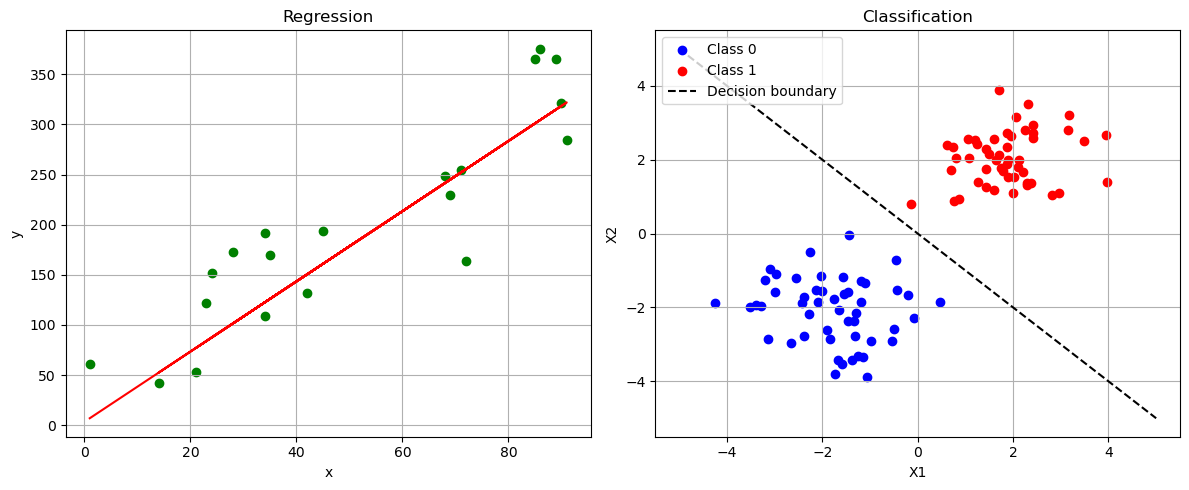

In [ ]:
np.random.seed(1326)

n = 20 # number observations for regression

X = np.random.randint(0,100,n)
y = 3 + 3.4 * X + np.random.normal(loc=0,scale=50,size=n)


m = 100 # number observations for classification
X1 = [np.random.normal(loc=-2,scale=.9,size=int(m/2)),np.random.normal(loc=2,scale=.9,size=int(m/2))]
X2 = [np.random.normal(loc=-2,scale=.9,size=int(m/2)),np.random.normal(loc=2,scale=.9,size=int(m/2))]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X,y,color="green",label="Data")
ax[0].plot(X,(3.4 + 3.5*X),color="r")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Regression")
ax[0].grid()


ax[1].scatter(X1[0], X2[0], color="blue", label="Class 0")
ax[1].scatter(X1[1], X2[1], color="red", label="Class 1")
ax[1].plot(np.linspace(-5, 5, 100), -np.linspace(-5, 5, 100), color="black", linestyle="--", label="Decision boundary")
ax[1].set_xlabel("X1")
ax[1].set_ylabel("X2")
ax[1].set_title("Classification")
ax[1].legend(loc=2)
ax[1].grid()


plt.tight_layout()
plt.show()

<a class="anchor" id="model"></a>
## 6. Model and Parameters

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


New Features

| $x_1$ | $x_2$ |
|----|----|
| 6  | 3300 | 
| 5  | 3100 |

$\Downarrow$ **Model** $\underbrace{f_\theta : \mathcal{X} \rightarrow \mathbb{R}}_{\text{Regression}}, \overbrace{\underbrace{f_\theta : \mathcal{X} \rightarrow \mathbb{R}^g}_{\text{Classification}}}^{g\text{ is number of classes}}$

Predictions

|$\hat{y}$ |
|---|
|2050|
|2200|

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

<h5 style="text-align:center;"><u>Hypothesis space</u></h5>

<u>Problem:</u> Without restrictions on the functional family finding the best model among all possible models is impossible.

<u>Solution:</u> Determine the functional family of the model *a priori* called *a structural priot* 




<h5 style="text-align:center;">Function view</h5>

(1) A model is chosen from a restricted set of functions of a certain form called the **hypothesis space $\mathcal{H}$**.

$$
\mathcal{H} = \{f : f \text{ belongs to a certain functional family}\}
$$


**Among all functions in the hypothesis space, choose the one that fits to data best.**

Example: Decision trees

$$
\mathcal{H} = \{\text{all decision tree functions of depth }\leq 3\}
$$

<h5 style="text-align:center;">Parameter view</h5>

(2) A model is chosen from a restricted set of **parametrized** functions of a certain form called the **hypothesis space $\mathcal{H}$**.

$$
\mathcal{H} = \{f_\theta : f_\theta \text{ belongs to a certain functional family parametrized by }\theta \in \Theta \}
$$

**Finding the optimal model means finding the optimal set of parameters $\theta=(\theta_0,....,\theta_{p-1})$ from the parameter space $\Theta$.**

Example: Simple linear functions

$$
\mathcal{H} = \{ f: f(x) = \theta_0 + \theta_1 \cdot x \mid \theta=(\theta_0, \theta_1) \in \mathbb{R}^2=\Theta \}
$$


</div>

</div>

<a class="anchor" id="learn"></a>
## 7. Learner

A learner (learning algorithm) is the procedure that:

1. Takes training data
2. Searches through possible models
3. Finds the best model out of the **hypothesis space $\mathcal{H}$** that fits the training data best according to some loss or risk measure.

Formally, the learner is written as:

$$
\underbrace{\mathcal{I}:\mathbb{D} \times \Lambda \rightarrow \mathcal{H}}_{\text{Function view}}, \hspace{2mm}  \underbrace{\mathcal{I}:\mathbb{D} \times \Lambda \rightarrow \Theta}_{\text{Parameter view}} 
$$

Where:
- $\mathbb{D} \rightarrow$ set of all finite datasets of size $n$ with $\mathcal{D} \in \mathbb{D}$
- $\mathrm{\Lambda} \rightarrow$ hyperparameters (settings of the algorithm) with vector of hyperparameters $\lambda \in \mathrm{\Lambda}$
- $\Theta \rightarrow$ parameter space (set of possible parameters with $\theta \in \Theta$)
- $\mathcal{H} \rightarrow$ restricted set of functions of a certain form



<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">


Example: Predict house prices

Training data:

| Size | Rooms | Price |
| ---- | ----- | ----- |
| 100  | 3     | 200k  |
| 150  | 4     | 300k  |

The learner:
1. tries many possible models
2. measures their prediction error
3. selects the one with the lowest error.

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
<!--color:white;-->
width:50%;
">

Important difference between Learners and Models:

| Concept | Meaning                         |
| ------- | ------------------------------- |
| Model   | Function that makes predictions |
| Learner | Algorithm that finds the model, i.e. finds best $\theta$  |



```python
from sklearn.linear_model import LinearRegression

model = LinearRegression() # learner

model.fit(X_train, y_train) # .fit() -> training process

model.predict(X_test) # model predictions
```


</div>

</div>


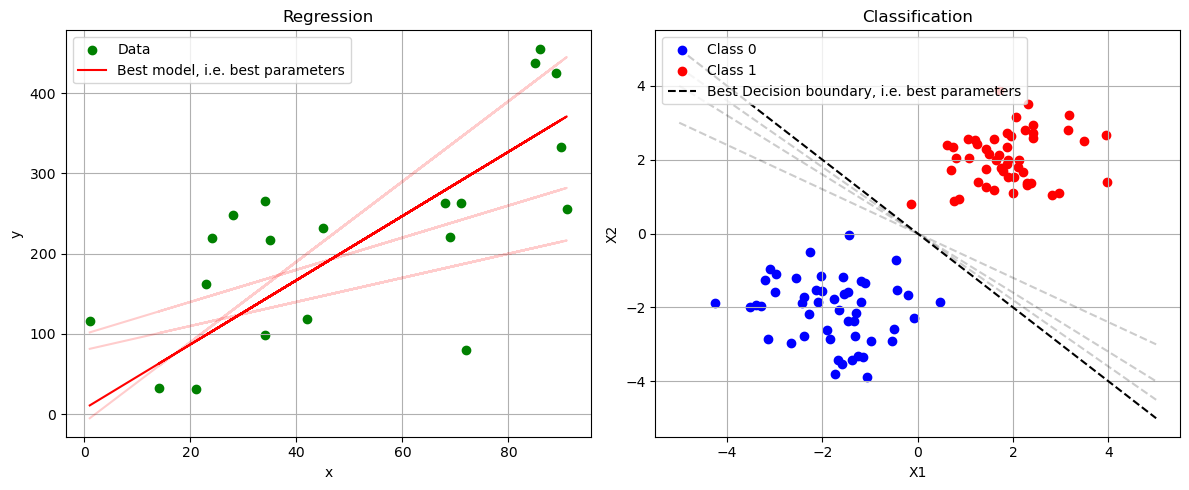

In [4]:
np.random.seed(1326)

n = 20 # number observations for regression

X = np.random.randint(0,100,n)
y = 3 + 3.4 * X + np.random.normal(loc=0,scale=100,size=n)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X,y,color="green",label="Data")
ax[0].plot(X,(7 + 4*X),color="r",label="Best model, i.e. best parameters")
ax[0].plot(X,(100 + 2*X),color="r",alpha=0.2)
ax[0].plot(X,(80 + 1.5*X),color="r",alpha=0.2)
ax[0].plot(X,(-10 + 5*X),color="r",alpha=0.2)
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].set_title("Regression")
ax[0].legend()
ax[0].grid()


m = 100 # number observations for classification
X1 = [np.random.normal(loc=-2,scale=.9,size=int(m/2)),np.random.normal(loc=2,scale=.9,size=int(m/2))]
X2 = [np.random.normal(loc=-2,scale=.9,size=int(m/2)),np.random.normal(loc=2,scale=.9,size=int(m/2))]

ax[1].scatter(X1[0], X2[0], color="blue", label="Class 0")
ax[1].scatter(X1[1], X2[1], color="red", label="Class 1")
ax[1].plot(np.linspace(-5, 5, 100), -np.linspace(-5, 5, 100), color="black", linestyle="--", label="Best Decision boundary, i.e. best parameters")
ax[1].plot(np.linspace(-5, 5, 100), -np.linspace(-4, 4, 100), color="black", linestyle="--",alpha=0.2)
ax[1].plot(np.linspace(-5, 5, 100), -np.linspace(-3, 3, 100), color="black", linestyle="--",alpha=0.2)
ax[1].plot(np.linspace(-5, 5, 100), -np.linspace(-4.5, 4.5, 100), color="black", linestyle="--",alpha=0.2)
ax[1].set_xlabel("X1")
ax[1].set_ylabel("X2")
ax[1].set_title("Classification")
ax[1].legend(loc=2)
ax[1].grid()


plt.tight_layout()
plt.show()

<a class="anchor" id="loss"></a>
## 8. Loss Function

**Loss measures prediction error for one observation.**


$$
L(y,f(x)) = \underbrace{(y - f(x))^2}_{\text{Squared error}} \hspace{2mm} \mid  \hspace{2mm} L(y,f(x)) = \underbrace{\mid y - f(x) \mid}_{\text{Absolute loss}}
$$



<a class="anchor" id="risk"></a>
## 9. Risk (Model Error)

**Risk measures overall model error.**



$$
\underbrace{\mathcal{R}(f) := \overbrace{\mathbb{E}_{(x,y) \sim \mathbb{P}_{xy}}[L(y,f(x))]}^{\text{Expected loss}} = \int L(y,f(x)) d\mathbb{P}_{xy}}_{\text{Theoretical risk of a candidate model } f}
$$

- $\mathbb{P}_{xy}$ is the probability distribution which is assumed to genertae the observed data $\mathcal{D}$ defined on $\mathcal{X} \times \mathcal{Y}$ in Notation $(x^{(i)},y^{(i)}) \sim \mathbb{P}_{xy}$
- We also assume that each data point from $\mathbb{P}_{xy}$ is independent from each other (i.e. when sampling house data do not sample all from same neighborhood since they may influence each other) in Notation $(x^{(i)},y^{(i)})  \overset{\text{i.i.d.}}{\sim} \mathbb{P}_{xy}$

**But we don't know the real data distribution.**

So we use **empirical risk**:

$$
\overbrace{\underbrace{\mathcal{R}_{\text{emp}}(f) = \sum_{i=1}^n L(y^{(i)},f(x^{(i)}))}_{\mathcal{R}_{\text{emp}}:\mathcal{H} \rightarrow \mathbb{R}}}^{\text{Function view}} \hspace{2mm} \mid  \hspace{2mm} \overbrace{\underbrace{\mathcal{R}_{\text{emp}}(\theta) = \sum_{i=1}^n L(y^{(i)},f_{\theta}(x^{(i)}))}_{\mathcal{R}_{\text{emp}}:\mathbb{R}^p \rightarrow \mathbb{R}}}^{\text{Parameter view}} 
$$



           L1 loss        L2 loss
1       112.181851   12584.767589
2       135.816404   18446.095623
3        86.905978    7552.649052
4        61.698803    3806.742310
5        54.777774    3000.604498
6        61.565363    3790.293874
7        56.840681    3230.863036
8        21.335583     455.207109
9       140.721907   19802.655075
10      156.281891   24424.029448
11       45.462706    2066.857594
12       81.751043    6683.233106
R_emp  1015.000000  105844.000000


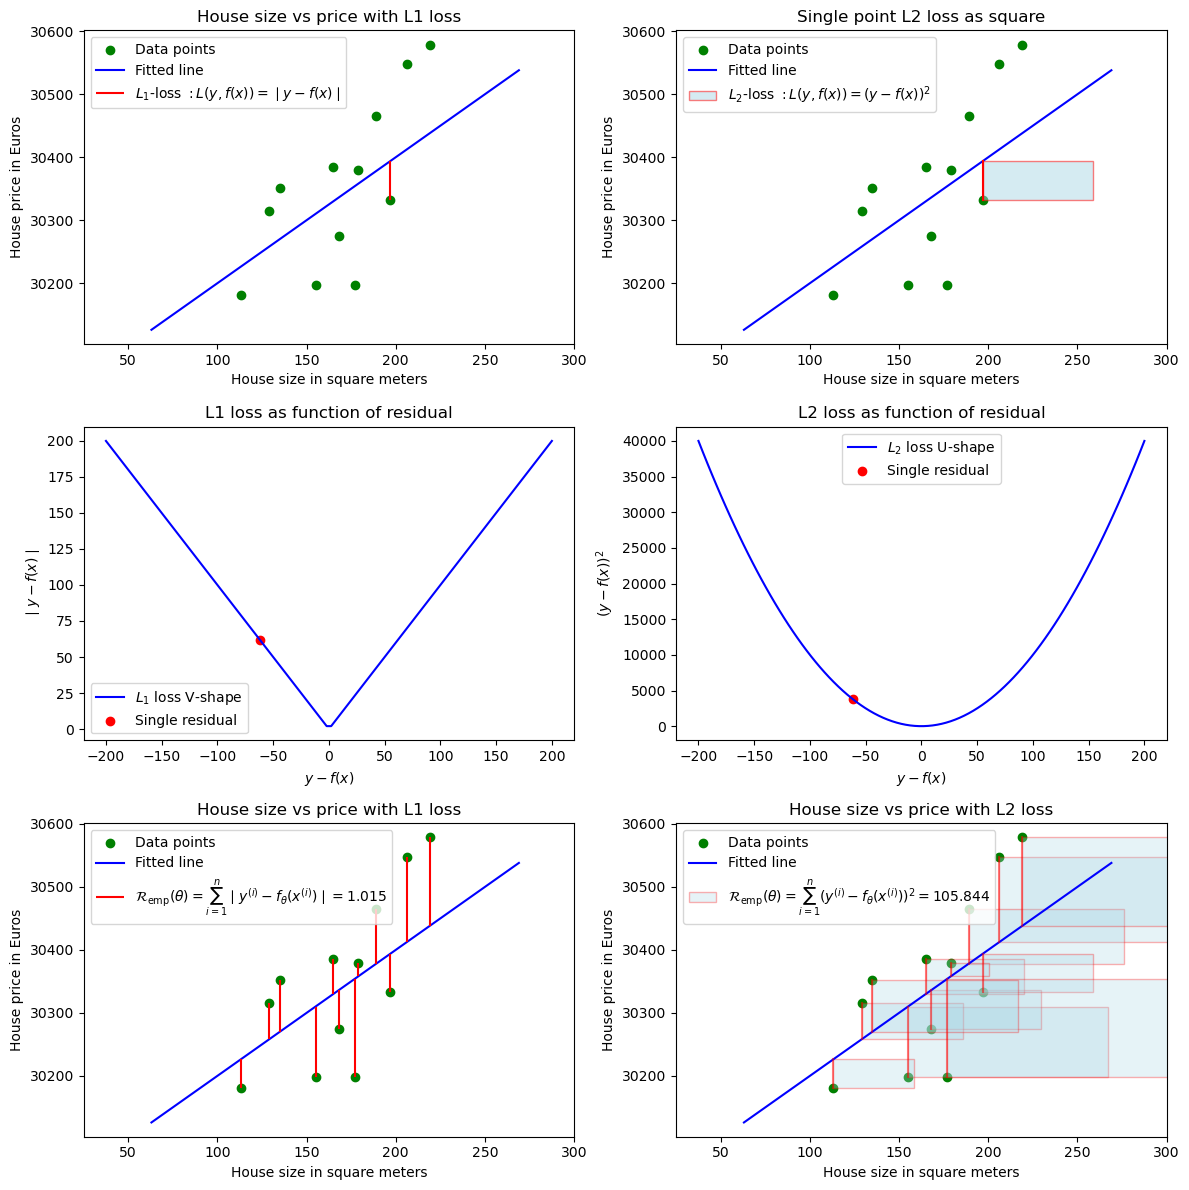

In [199]:
np.random.seed(1115) # for reproducibility of random numbers

n = 12 # number of observations

house_size = np.random.randint(75,250,n) # house size in square meters
incr = 2 # 2€ increase per square meter
gaussian_noise = np.random.normal(loc=0, scale=100, size=n) # distortion of relationship between Price and Size
base_price = 30000 # predicted price when house_size = 0 (not logical)
true_house_price = base_price + incr*house_size # true relations
house_price = true_house_price + gaussian_noise # house price increases by about 2€ per square meter with Gaussian noise (std = 100)
# house price = base price 30000€ + 2€ per square meter

x = np.linspace(np.min(house_size)-50, np.max(house_size)+50, 100) # extend house sizes beyond observed data


L1 = np.abs(house_price - true_house_price)
L2 = (house_price - true_house_price)**2

df = pd.DataFrame({
    "L1 loss": list(L1) + [np.round(np.sum(L1))],
    "L2 loss": list(L2) + [np.round(np.sum(L2))]},
    index=[str(i+1) for i in range(n)] + ["R_emp"])

print(df)

plt.figure(figsize=(12,12)) 
nrows=3
ncols=2


# 1 Plot: Plot of L1 Loss for one data point
plt.subplot(nrows,ncols,1)
plt.scatter(house_size, house_price,color="green",label="Data points")
plt.plot(x,base_price + incr*x,color="b",label="Fitted line") # fitted line 

# empirircal risk for each data point
plt.vlines(house_size[5], true_house_price[5], house_price[5],colors="red", alpha=1,label=r"$L_1 \text{-loss }:L(y,f(x))=\mid y-f(x) \mid$")

plt.xlabel("House size in square meters")
plt.xlim((25,300))
plt.ylabel("House price in Euros")
plt.title("House size vs price with L1 loss")
plt.legend(loc=0)

# ---------------------------

import matplotlib.patches as patches

# 2 Plot: L2 Loss for one data point with square visualization
plt.subplot(nrows,ncols,2)
plt.scatter(house_size, house_price, color="green", label="Data points")
plt.plot(x, base_price + incr*x, color="b", label="Fitted line")  # fitted line

# L2 loss for observation 5
x_obs = house_size[5]
y_obs = house_price[5]
y_pred = base_price + incr*x_obs
residual = y_obs - y_pred

# Draw square representing L2 loss
square_side = np.abs(residual)
square = patches.Rectangle(
    (x_obs, min(y_obs, y_pred)),  # bottom-left corner
    width=square_side,             # width proportional to residual
    height=square_side,            # height = residual
    edgecolor='red',
    facecolor='lightblue',
    alpha=0.5,
    label=r"$L_2 \text{-loss }:L(y,f(x))=(y-f(x))^2$"
)
plt.gca().add_patch(square)

# Connect observed point to predicted point with red line
plt.plot([x_obs, x_obs], [y_pred, y_obs], color="red")

plt.xlabel("House size in square meters")
plt.ylabel("House price in Euros")
plt.title("Single point L2 loss as square")
plt.legend(loc=0)
plt.xlim(25, 300)

# ---------------------------

# 3 Plot: Plot of L1 loss with y-f(x) as x axis and |y-f(x)| as y axis (V shape)
plt.subplot(nrows,ncols,3)
residual = house_price - (base_price + incr*house_size)
residual_line = np.linspace(-200, 200, 100)
plt.plot(residual_line, np.abs(residual_line), color="blue", label=r"$L_1$ loss V-shape")
plt.scatter(residual[5], np.abs(residual[5]), color="red", label="Single residual")
plt.xlabel(r"$y-f(x)$")
plt.ylabel(r"$\mid y-f(x) \mid$")
plt.title("L1 loss as function of residual")
plt.legend(loc=0)


# ---------------------------

# 4 Plot: Plot of L2 loss with y-f(x) as x axis and (y-f(x)) as y axis (U-shape)
plt.subplot(nrows,ncols,4)
plt.plot(residual_line, residual_line**2, color="blue", label=r"$L_2$ loss U-shape")
plt.scatter(residual[5], residual[5]**2, color="red", label="Single residual")
plt.xlabel(r"$y-f(x)$")
plt.ylabel(r"$(y-f(x))^2$")
plt.title("L2 loss as function of residual")
plt.legend(loc=0)


# ---------------------------

# 5 Plot: Plot of L1 Loss for all data points
plt.subplot(nrows,ncols,5)
plt.scatter(house_size, house_price,color="green",label="Data points")
plt.plot(x,base_price + incr*x,color="b",label="Fitted line") # fitted line 
for i in range(n):

    # empirircal risk for each data point
    plt.vlines(
        house_size[i], true_house_price[i], house_price[i],
        colors="red", alpha=1,
        label=r"$\mathcal{R}_{\mathrm{emp}}(\theta)=\sum_{i=1}^n \mid y^{(i)}-f_\theta(x^{(i)}) \mid=1.015$" if i == 0 else ""
    )


plt.xlabel("House size in square meters")
plt.xlim((25,300))
plt.ylabel("House price in Euros")
plt.title("House size vs price with L1 loss")
plt.legend(loc=0)

# ---------------------------

# 6 Plot: Plot of L2 Loss for all data points
plt.subplot(nrows,ncols,6)
plt.scatter(house_size, house_price,color="green",label="Data points")
plt.plot(x,base_price + incr*x,color="b",label="Fitted line") # fitted line 


for i in range(n):

    x_obs = house_size[i]
    y_obs = house_price[i]
    y_pred = base_price + incr*x_obs
    residual = y_obs - y_pred

    square_side = np.abs(residual)

    square = patches.Rectangle(
        (x_obs, min(y_obs, y_pred)),   # bottom-left corner
        width=square_side,
        height=square_side,
        edgecolor="red",
        facecolor="lightblue",
        alpha=0.3,
        label=r"$\mathcal{R}_{\mathrm{emp}}(\theta)=\sum_{i=1}^n ( y^{(i)}-f_\theta(x^{(i)}) )^2=105.844$" if i == 0 else ""
    )

    plt.gca().add_patch(square)

    # optional: draw the residual line (helps visually)
    plt.plot([x_obs, x_obs], [y_pred, y_obs], color="red", alpha=0.5)


plt.xlabel("House size in square meters")
plt.xlim((25,300))
plt.ylabel("House price in Euros")
plt.title("House size vs price with L2 loss")
plt.legend(loc=0)



plt.tight_layout()
plt.show()



<a class="anchor" id="erm"></a>
## 10. Empirical Risk Minimization (ERM)

Machine learning trains models by minimizing empirical risk.

$$
\hat{\theta} = \arg \min_{\theta \in \Theta} \mathcal{R}_{\text{emp}}(\theta)
$$

**Goal:** Find parameters that minimize prediction error.



**Idea:** Rotate fitted line around center which is $(\text{mean\_x}, \text{mean\_y})=(\bar{x},\bar{y})$ clock-wise or counter clock wise.

Setup:
- $\mathcal{H}={f_\theta: f_\theta = \theta_0 + \theta_1 \cdot x \mid \theta \in \Theta = \mathbb{R}^2}$

Procedure (counter-clock wise):
- Start with Model 1: $f_\theta = \bar{y} + 0 \cdot x$
- Create rotation of line by adjusting $\theta_0$ and $\theta_1$
    - For a line $f_\theta = \theta_0 + \theta_1 \cdot x$ passing through $(\bar{x},\bar{y})$ means $\bar{y}=\theta_0 + \theta_1 \cdot \bar{x}$ so $\theta_0 = \bar{y}-\theta_1 \cdot \bar{x}$
- During rotation only stepwise increase the slope $\theta_1$ and recompute the intercept so the pivot point $(\bar{x},\bar{y})$ stays fixed

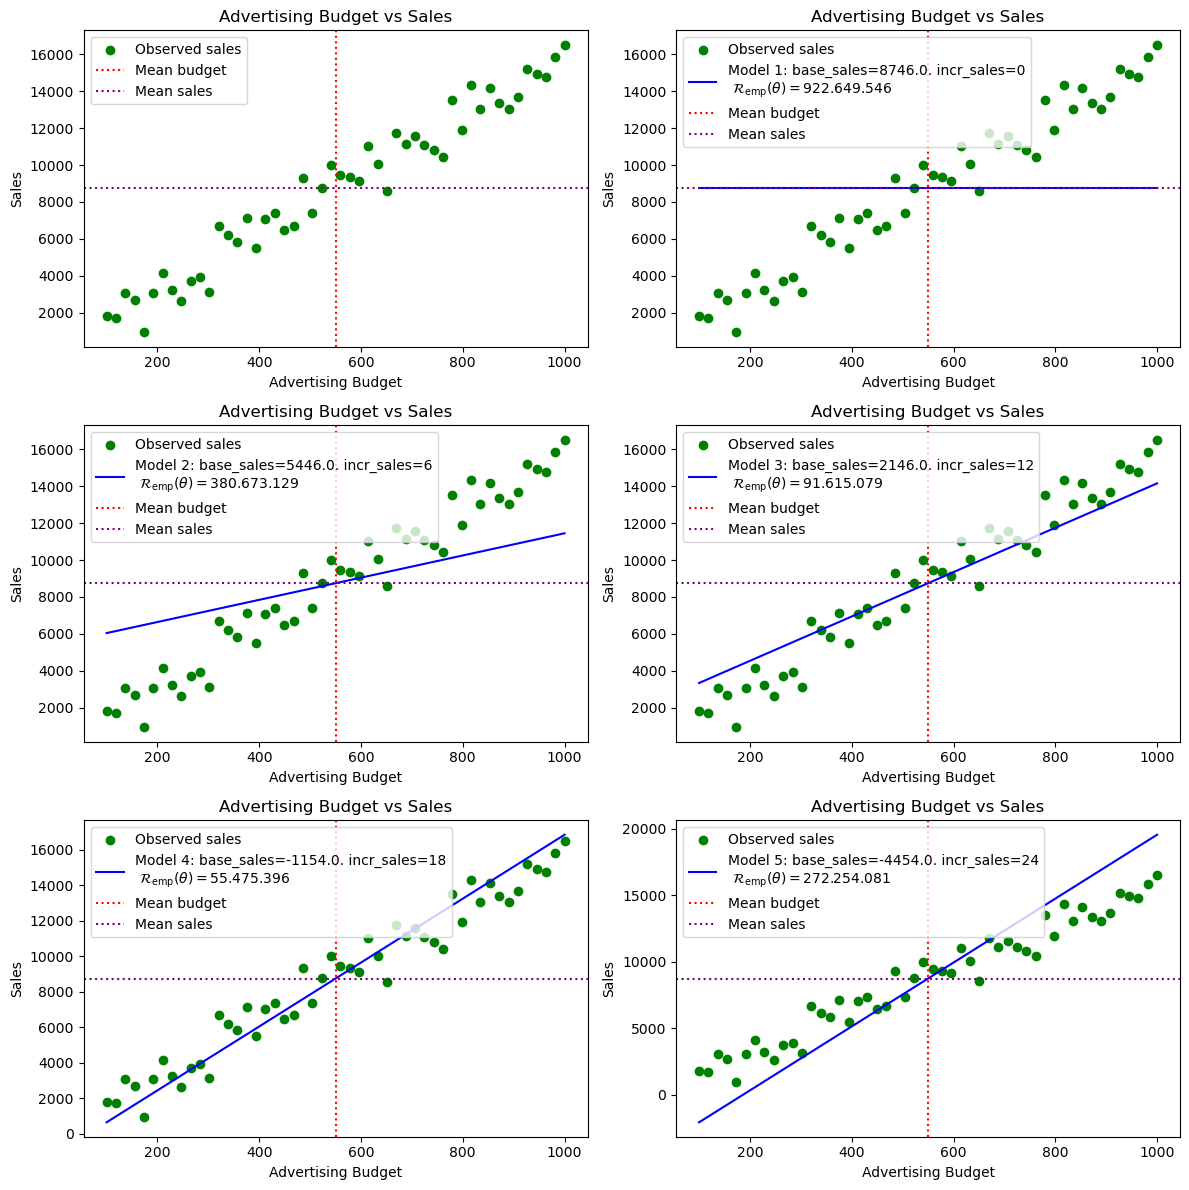

In [297]:
def emp_risk(y,y_pred):
    return np.sum((y-y_pred)**2)


np.random.seed(2010) 

n = 50 # number observations

x = np.linspace(100,1000,n) # companies advertising budget for some year (not real)
base_sales = 400 # product sales if advertising budget = 0
incr_sales = 15 # increase in sales per unit increase in budget 
true_sales = base_sales + incr_sales * x # true linear relationship
distortion = np.random.normal(loc=0,scale=850,size=n) # random noise
sales = true_sales + distortion # observed sales with noise

mean_budget = np.mean(x)
mean_sales = np.mean(sales)


plt.figure(figsize=(12,12)) 
nrows=3
ncols=2

plt.subplot(nrows,ncols,1)
plt.scatter(x, sales, color="green", label="Observed sales")

# mean lines
plt.axvline(mean_budget, linestyle="dotted", color="red", label="Mean budget")
plt.axhline(mean_sales, linestyle="dotted", color="purple", label="Mean sales")

plt.xlabel("Advertising Budget")
plt.ylabel("Sales")
plt.title("Advertising Budget vs Sales")
plt.legend()

base_sales = mean_sales
incr_sales = 0

slope_step = 6  # controls how much the line rotates each step

for i in range(2,7):

    plt.subplot(nrows,ncols,i)
    plt.scatter(x, sales, color="green", label="Observed sales")

    # rotate line by increasing slope
    incr_sales = (i-2) * slope_step # multiply with (i-2) so that at beginning slope is 0

    # adjust intercept so line passes through (mean_budget, mean_sales)
    base_sales = mean_sales - incr_sales * mean_budget 

    sales_pred = base_sales + incr_sales * x
    risk = emp_risk(sales, sales_pred)

    lab = f"Model {i-1}: base_sales={np.round(base_sales)}, incr_sales={np.round(incr_sales,4)}\n $\mathcal{{R}}_{{\mathrm{{emp}}}}(\\theta)={risk:,.0f}$".replace(",", ".")

    plt.plot(x, sales_pred, color="blue", label=lab)

    plt.axvline(mean_budget, linestyle="dotted", color="red", label="Mean budget")
    plt.axhline(mean_sales, linestyle="dotted", color="purple", label="Mean sales")

    plt.xlabel("Advertising Budget")
    plt.ylabel("Sales")
    plt.title("Advertising Budget vs Sales")
    plt.legend(loc=2)


plt.tight_layout()
plt.show()


<a class="anchor" id="optim"></a>
## 11. Optimization (Gradient Descent)

**Gradient descent is an iterative optimization algorithm often used to minimize the risk.**

Instead of checking every parameter combination, we:


1. Start with random parameters
2. Compute the gradient (slope of the error surface) with respect to $\theta$ at some point $\theta^{[t]}$
    - $ \nabla \mathcal{R}_{\text{emp}}(\theta^{[t]}) = \frac{ \partial \mathcal{R}_{\text{emp}}}{ \partial \theta}(\theta^{[t]})$ with $\nabla \mathcal{R}_{\text{emp}} = \begin{pmatrix} \frac{ \partial \mathcal{R}_{\text{emp}}}{\partial \theta_0} & ... & \frac{ \partial \mathcal{R}_{\text{emp}}}{ \partial \theta_{p-1}}  \end{pmatrix}^\top$
3. Move in the direction that reduces error with $-\frac{ \partial \mathcal{R}_{\text{emp}}}{ \partial \theta}(\theta^{[t]})$ and control step size with $\alpha$

    - Update rule:

    $$
    \theta^{[t+1]}=\theta^{[t]} -\alpha \frac{ \partial \mathcal{R}_{\text{emp}}}{ \partial \theta}(\theta^{[t]})
    $$

    - Where:
        - $\alpha \rightarrow$ learning rate
        - gradient $\frac{ \partial \mathcal{R}_{\text{emp}}}{ \partial \theta}(\theta^{[t]}) \rightarrow$ direction of steepest increase at point $\theta^{[t]}$
        - move opposite direction, so in direction with steepest decrease $\rightarrow -\frac{\partial \mathcal{R}_{\text{emp}}}{ \partial \theta}(\theta^{[t]})$ and control steps $\rightarrow -\alpha \frac{ \partial \mathcal{R}_{\text{emp}}}{d\theta}(\theta^{[t]})$

4. Repeat until convergence (i.e. updated $\theta$ does not change much or gradient approaches 0)


##### Local vs Global Minimum

A local minimum is a point where *small changes increase error* but it might not be the best overall minimum.

**Definition of local minimum for parameter vector $\hat{\theta}$:**
 
$\quad \quad \hat{\theta}$ is a local minimum if $\exists \epsilon \ge 0 \hspace{1mm} \forall \theta$ with $\lVert \hat{\theta}-\theta \rVert \le \epsilon : \mathcal{R}_{\text{emp}}(\hat{\theta}) \leq \mathcal{R}_{\text{emp}}(\theta)$ or in other words $\mathcal{R}_{\text{emp}}(\hat{\theta}) \leq \mathcal{R}_{\text{emp}}(\theta)$ for all nearby $\theta$


Gradient descent may stop at:

- local minimum
- global minimum
- saddle point

depending on the error surface and the random start parameters.

<p align="center">
<img src="local_global_min.jpg" width="350"/>
</p>


##### Local minimum sufficient conditions
Given that $\mathcal{R}_{\text{emp}}(\theta)$ is continuously differentiable with respect to $\theta$ we have two conditions:
1. $\hat{\theta}$ is stationary meaning $\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta}(\hat{\theta})=0$
2. Hessian $\nabla^2  \mathcal{R}_{\text{emp}}(\hat{\theta})$ at $\hat{\theta}$ is positive definite meaning  

$$
z^\top \nabla^2  \mathcal{R}_{\text{emp}}(\hat{\theta}) z =
z^\top \begin{pmatrix} 
\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_0 \partial \theta_0}(\hat{\theta}) &\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_0 \partial \theta_1}(\hat{\theta}) & \cdots & \frac{ \partial \mathcal{R}_{\text{emp}}}{\partial \theta_{0}\partial \theta_{p-1}}(\hat{\theta}) \\ 

\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_1 \partial \theta_0}(\hat{\theta}) &\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_1 \partial \theta_1}(\hat{\theta}) & \cdots & \frac{ \partial \mathcal{R}_{\text{emp}}}{\partial \theta_{1}\partial \theta_{p-1}}(\hat{\theta}) \\ 

\vdots & \vdots & \cdots & \vdots \\

\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_{p-1} \partial \theta_0}(\hat{\theta}) &\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_{p-1} \partial \theta_1}(\hat{\theta}) & \cdots & \frac{ \partial \mathcal{R}_{\text{emp}}}{\partial \theta_{p-1}\partial \theta_{p-1}}(\hat{\theta}) \\ 

\end{pmatrix} z \geq \begin{pmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{pmatrix}
$$


##### Learning rate $\alpha$

The learning rate controls step size.

<div style="display:flex; gap:20px;">

<!-- Intercept -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Small $\alpha$
- slow convergence
- stable

</div>


<!-- Slope -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Good $\alpha$
- fast convergence

</div>


<!-- Example or other test -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Too large $\alpha$
- overshoot minimum
- algorithm may diverge

</div>

</div>

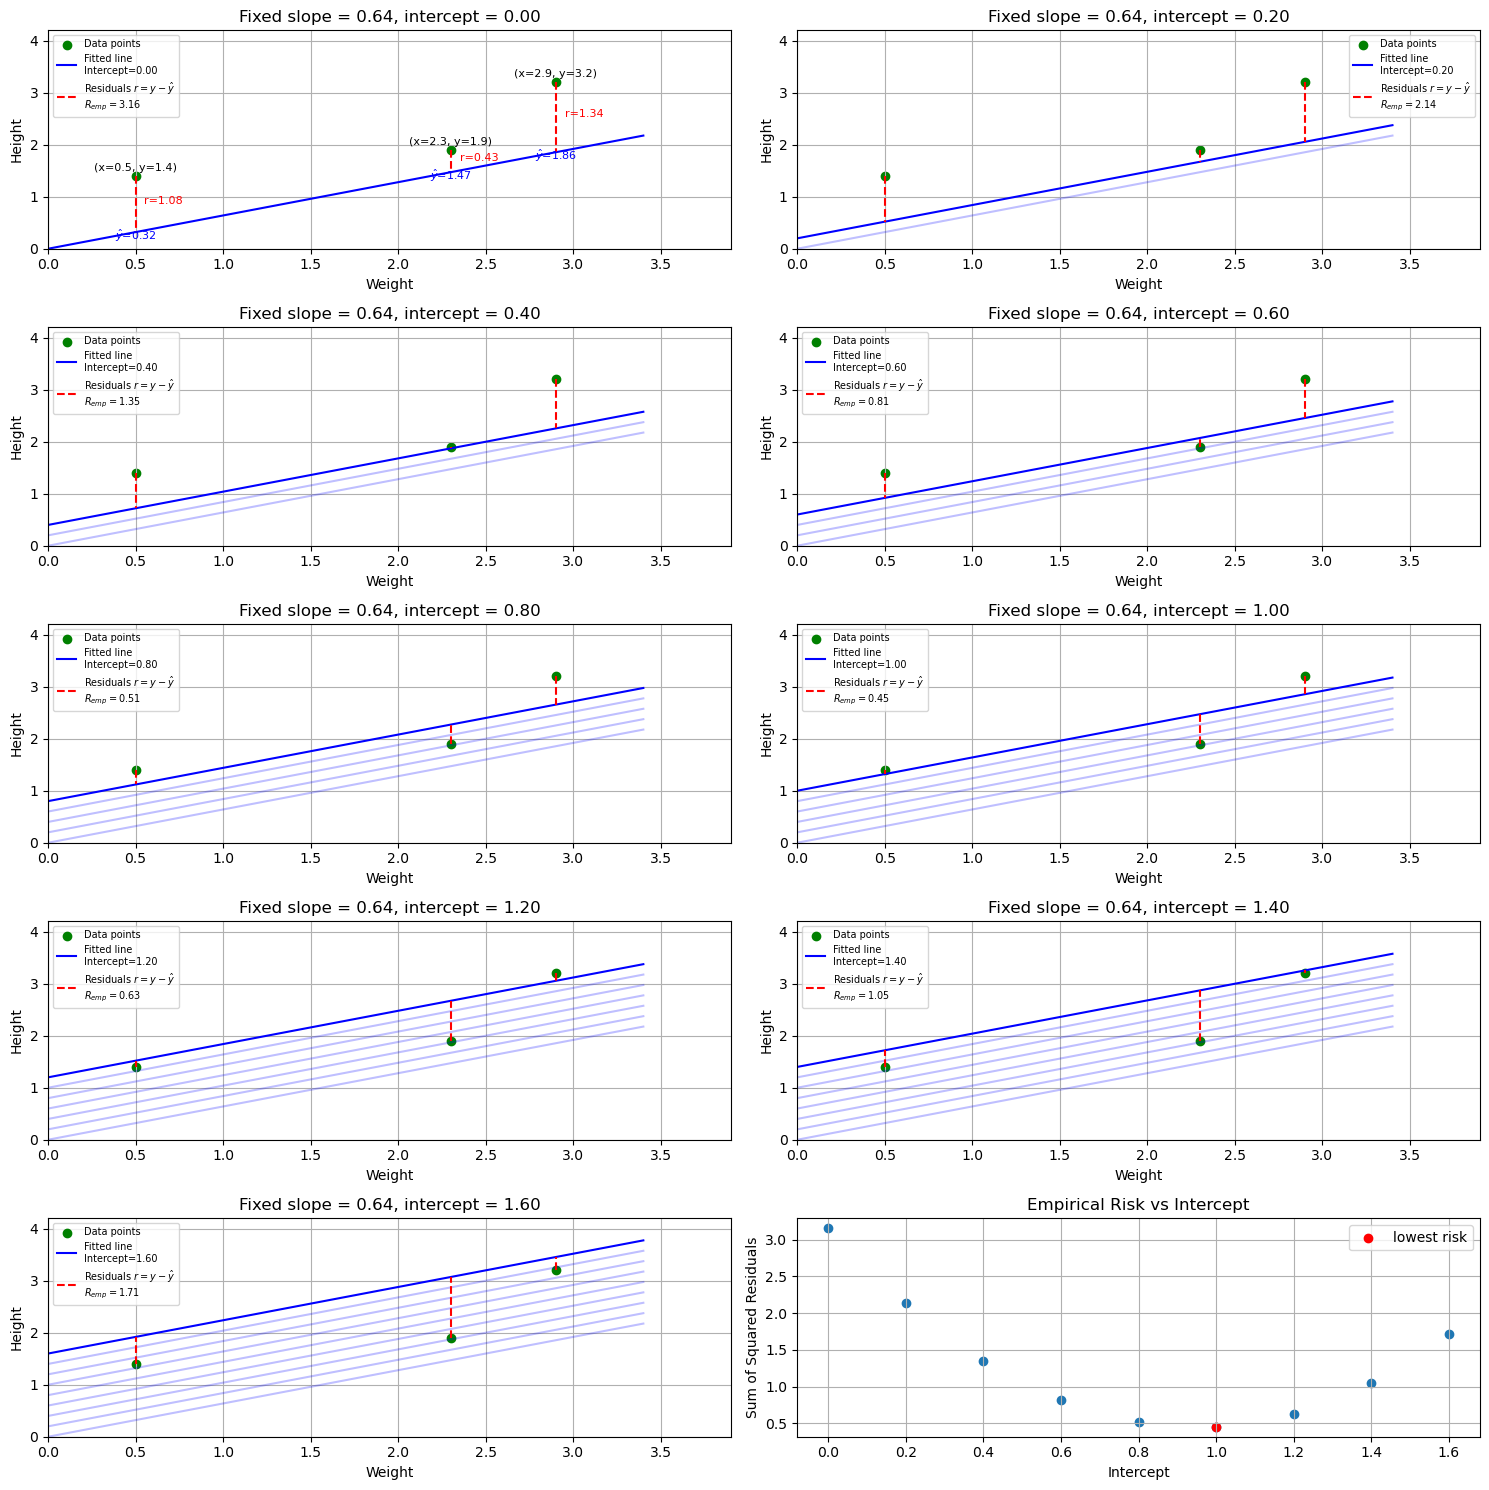

In [ ]:
# data
height = np.array([1.4,1.9,3.2]) 
weight = np.array([0.5,2.3,2.9])

x = np.linspace(0, np.max(weight)+0.5, 100) # used for smooth more continuous predictions

# Goal: Find best intercept (with fixed slope) to fit a line to the data

# Approach 1: Manually try out a few different intercepts

intercept = 0 # start with intercept = 0
fixed_slope = 0.64 # slope never changes

nrows, ncols = 5, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,15))
axes = axes.flatten() # used so axes[k] works

# arrays to store results
intercepts = []
emp_risks = []

for k in range(nrows*ncols):

    if k == nrows*ncols - 1: # last subplot will be used for risk curve
        break 

    axes[k].scatter(weight, height, color="g", label="Data points")

    # show all previous lines
    for prev_intercept in intercepts:
        axes[k].plot(x, prev_intercept + fixed_slope*x, color="blue", alpha=0.25)
    
    axes[k].plot(x, intercept + fixed_slope*x, color="blue",label=f"Fitted line\nIntercept={intercept:.2f}")



    y_pred_all = intercept + fixed_slope * weight # predictions for all points

    R_emp = np.sum((height - y_pred_all)**2) # empirical risk

    # store values
    intercepts.append(intercept)
    emp_risks.append(R_emp)

    for j in range(len(height)):

        y_pred = y_pred_all[j]
        residual = height[j] - y_pred

        axes[k].vlines(
            weight[j], height[j], y_pred,
            colors="red",
            linestyles="--",
            alpha=1,
            label=f"Residuals $r=y-\\hat{{y}}$\n$R_{{emp}}={R_emp:.2f}$" if j == 0 else ""
        )

        if k == 0: # only display text for first plot

            axes[k].text(weight[j], height[j] + 0.1,
                         f"(x={weight[j]}, y={height[j]})",
                         ha="center", fontsize=8)

            axes[k].text(weight[j], y_pred - 0.15,
                         f"$\\hat{{y}}$={y_pred:.2f}",
                         color="blue", ha="center", fontsize=8)

            axes[k].text(weight[j] + 0.05,
                         (height[j] + y_pred) / 2,
                         f"r={residual:.2f}",
                         color="red", fontsize=8)

    axes[k].set_xlabel("Weight")
    axes[k].set_xlim((0, np.max(weight)+1))
    axes[k].set_ylabel("Height")
    axes[k].set_ylim((0, np.max(height)+1))
    axes[k].set_title(f"Fixed slope = {fixed_slope}, intercept = {intercept:.2f}")
    axes[k].grid()
    axes[k].legend(fontsize=7)

    intercept += 0.2 # increase intercept


# convert to arrays
intercepts = np.array(intercepts)
emp_risks = np.array(emp_risks)

# last subplot: empirical risk vs intercept
axes[-1].scatter(intercepts, emp_risks)
axes[-1].scatter(intercepts[5], emp_risks[5],color="red",label="lowest risk")
axes[-1].set_title("Empirical Risk vs Intercept")
axes[-1].set_xlabel("Intercept")
axes[-1].set_ylabel("Sum of Squared Residuals")
axes[-1].grid()
axes[-1].legend()

plt.tight_layout()
plt.show()


# Problem with Approach 1: 

# Approach 1 tests intercept values manually with a fixed step size. This is inefficient because we must evaluate many candidate values, 
# and the true minimum might lie between two tested intercepts. 
# Furthermore, this brute-force search does not scale well to models with many parameters, 
# making it impractical for real machine learning problems.



$
\mathcal{D} = \left( \left(x^{(1)},y^{(1)}\right), \left(x^{(2)},y^{(2)}\right), \left(x^{(3)},y^{(3)}\right) \right)
= \left( \left(0.5,1.4\right), \left(2.3,1.9\right), \left(2.9,3.2\right) \right)
\in (\mathcal{X} \times \mathcal{Y})^3
$

$$
\begin{align}
\mathcal{R}_{\text{emp}}(\theta) 
&= \sum_{i=1}^3 L(y^{(i)},f(x^{(i)})) \\
&= \sum_{i=1}^3 (y^{(i)} - (\theta_0 + \theta_1 \cdot x^{(i)}))^2 \\
&=  (1.4 - (\theta_0 + 0.64 \cdot 0.5))^2 
+ (1.9 - (\theta_0 + 0.64 \cdot 2.3))^2 
+ (3.2 - (\theta_0 + 0.64 \cdot 2.9))^2
\end{align}
$$

$$
\begin{align}
\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_0} 
&= \frac{d}{d \theta_0}(1.4 - (\theta_0 + 0.64 \cdot 0.5))^2 
+ \frac{d}{d \theta_0}(1.9 - (\theta_0 + 0.64 \cdot 2.3))^2 
+ \frac{d}{d \theta_0}(3.2 - (\theta_0 + 0.64 \cdot 2.9))^2 \\
&= -2 \cdot (1.4 - (\theta_0 + 0.64 \cdot 0.5))
-2 \cdot (1.9 - (\theta_0 + 0.64 \cdot 2.3))
-2 \cdot (3.2 - (\theta_0 + 0.64 \cdot 2.9)) \hspace{1 mm} \mid \text{Chain rule} \\

\end{align}
$$



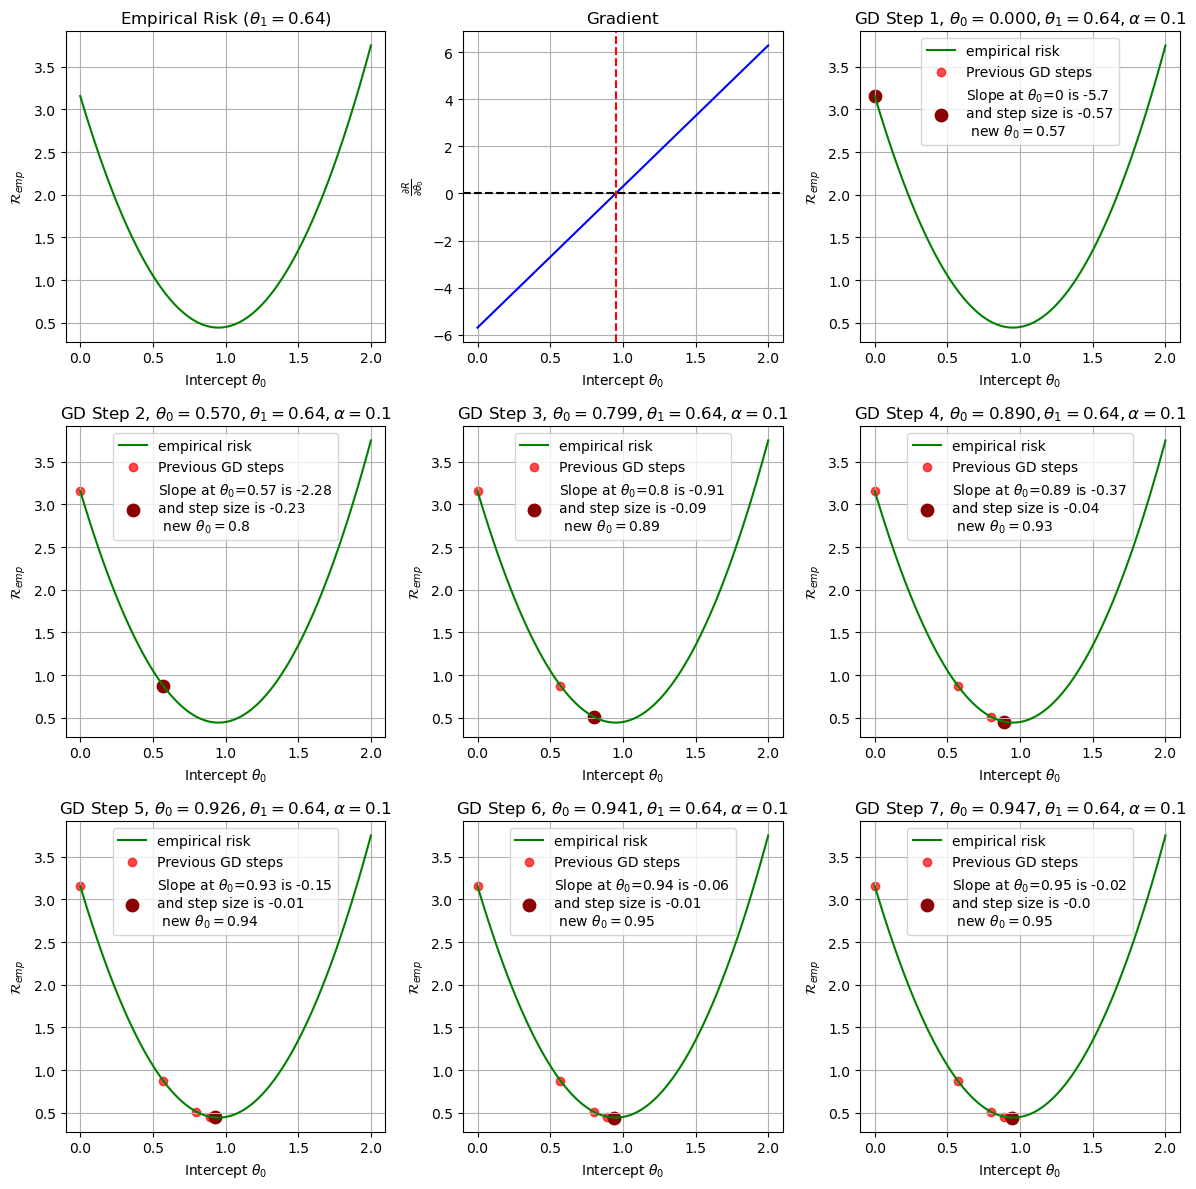

In [ ]:
# Approach 2: Gradient Descent

# data
height = np.array([1.4,1.9,3.2]) 
weight = np.array([0.5,2.3,2.9])

intercepts = np.linspace(0,2,100)
intercept = 0 # start intercept
alpha = 0.1 # learning rate 
#alpha = 0.3 # uncomment and try this one out 

# empirical risk function
def R_emp(intercept):
    return (
        (1.4 - (intercept + 0.64 * 0.5))**2 +
        (1.9 - (intercept + 0.64 * 2.3))**2 +
        (3.2 - (intercept + 0.64 * 2.9))**2
    )

# gradient
def gradient(intercept):
    return -2 * (
        (1.4 - (intercept + 0.64*0.5)) +
        (1.9 - (intercept + 0.64*2.3)) +
        (3.2 - (intercept + 0.64*2.9))
    )

# setup plots
nrow, ncol = 3,3
fig, ax = plt.subplots(nrows=nrow, ncols=ncol, figsize=(12,12))
ax = ax.flatten()

# risk curve
ax[0].plot(intercepts, [R_emp(i) for i in intercepts], color="g")
ax[0].set_title("Empirical Risk ($\\theta_1=0.64$)")
ax[0].set_xlabel("Intercept $\\theta_0$")
ax[0].set_ylabel("$\\mathcal{R}_{emp}$")
ax[0].grid()

# gradient curve
ax[1].plot(intercepts, [gradient(i) for i in intercepts], color="b")
ax[1].axhline(0, linestyle="--", color="black")  # horizontal zero line

# find intercept where gradient is closest to 0
grad_values = np.array([gradient(i) for i in intercepts])
min_index = np.argmin(np.abs(grad_values))
optimal_intercept = intercepts[min_index]

# vertical line at zero-gradient intercept
ax[1].axvline(optimal_intercept, linestyle="--", color="red",label=f"Gradient = 0 at $\\theta_0 \\approx {optimal_intercept:.2f}$")
ax[1].set_title("Gradient")
ax[1].set_xlabel("Intercept $\\theta_0$")
ax[1].set_ylabel(r"$\frac{\partial R}{\partial \theta_0}$")
ax[1].grid()

intercept_history = []
risk_history = []

# gradient descent visualization
for i in range(2, nrow*ncol):

    # store current state
    intercept_history.append(intercept)
    risk_history.append(R_emp(intercept))

    ax[i].plot(intercepts, [R_emp(j) for j in intercepts], color="g",label="empirical risk")

    # plot previous GD steps (faint red)
    ax[i].scatter(intercept_history, risk_history,
                color="red", alpha=0.7, label="Previous GD steps")

    current_risk = R_emp(intercept)

    current_slope = gradient(intercept) # gradient for current intercept
    ax[i].scatter(intercept, current_risk, color="darkred",s=80,
                  label=f"Slope at $\\theta_0$={np.round(intercept,2)} is {np.round(current_slope,2)}\nand step size is {np.round(alpha * current_slope,2)}\n new $\\theta_0={np.round(intercept - alpha * current_slope,2)}$")

    ax[i].set_title(f"GD Step {i-1}, $\\theta_0={intercept:.3f},\\theta_1 = 0.64,\\alpha={alpha}$")
    ax[i].set_xlabel("Intercept $\\theta_0$")
    ax[i].set_ylabel("$\\mathcal{R}_{emp}$")
    ax[i].grid()
    ax[i].legend()

    # gradient descent update
    intercept = intercept - alpha * current_slope

plt.tight_layout()
plt.show()


# Observation of Approach 2: 

# In Approach 2 gradient descent updates the intercept iteratively using the gradient, so the step sizes are automatically determined 
# by the slope of the risk function. When the gradient is large, the update step is large and as we approach the minimum, 
# the gradient becomes smaller and the steps shrink accordingly.





<a class="anchor" id="summary"></a>
## 12. Learner summary

### 1. The learner (inducer)
$$
\mathcal{I}
$$
is the learning algorithm.

Examples:
- Linear regression training
- Gradient descent
- Random forest training
- Neural network training

**It is called an inducer because it induces a model from data.**

----

### 2. Training data

The learner receives a training set
$$
\mathcal{D} \in \mathbb{D}
$$

Where:
- $\mathcal{D}$ = one specific dataset (features and targets)
- $\mathbb{D}$ = the set of all possible datasets (features and targets)


Example dataset:

| size | rooms | price  |
| ---- | ----- | ------ |
| 70   | 3     | 500000 |
| 80   | 4     | 650000 |

-----


### 3. Hypothesis space
$$
\mathcal{H}
$$
is the set of all models the algorithm is allowed to choose from.


-----

### 4. Risk function

The learner evaluates models using the empirical risk


$$
\mathcal{R}_{\text{emp}}(f)
$$

This measures how well the model fits the training data.

Example: Mean squared error

$$
\mathcal{R}_{\text{emp}}(f) = \frac{1}{n} \sum_{i=1}^n L(y^{(i)},f(x^{(i)})) \hspace{1 mm} \text{ multiplying with } \frac{1}{n} \text{ is common}
$$


-----

### 5. Parameterized models

If the model depends on parameters $\theta$, we write

$$
\mathcal{R}_{\text{emp}}(\theta) = \frac{1}{n} \sum_{i=1}^n L(y^{(i)},f_\theta(x^{(i)})) \hspace{1 mm} \text{ multiplying with } \frac{1}{n} \text{ is common}
$$



### 6. Optimization


The learner then searches for the best model

**Function view**

$$
\hat{f} = \arg \min_{f \in \mathcal{H}} \mathcal{R}_{\text{emp}}(f)
$$

Goal: Choose the best model from the hypothesis space.


**Parameter view**

$$
\hat{\theta} = \arg \min_{\theta \in \Theta} \mathcal{R}_{\text{emp}}(\theta)
$$

Goal: Choose the parameter vector that minimzes $\mathcal{R}_{\text{emp}}(\theta)$ the most.

----

### 7. Hyperparameters

$$
\lambda \in \Lambda
$$

are hyperparameters chosen outside the learning process.

Examples:

- model complexity in polynomial regression
- regularization strength in Ridge/Lasso Regression
- tree depth in Decision Trees
- number of neighbors in k-Nearest Neighbors

------

### 8. The learning algorithm as a mapping

The learner can be viewed as a function

$$
\underbrace{\mathcal{I}:\mathbb{D} \times \Lambda \rightarrow \mathcal{H}}_{\text{Function view}}, \hspace{2mm}  \underbrace{\mathcal{I}:\mathbb{D} \times \Lambda \rightarrow \Theta}_{\text{Parameter view}} 
$$


<a class="anchor" id="com"></a>
## 13. Components of Supervised Learning

**Machine Learning = $\underbrace{\text{Hypothesis Space}}_{\text{Defines model }f}$ + $\underbrace{\text{Risk/Loss function}}_{\text{Performance measure of model }f}$ + $\underbrace{\text{Optimization}}_{\text{Defines Performance measure}}$**

<div style="display:flex; gap:20px;">

<!-- Intercept -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Hypothesis Space examples:
- Linear Functions
- Neural networks

</div>


<!-- Slope -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Risk/Loss function examples:
- Mean squarred error (MSE)
- Missclassification rate
- Negative log-likelihood

</div>


<!-- Example or other test -->
<div style="
padding:16px;
border-radius:8px;
width:33%;
">

Optimization examples:
- Gradient descent
- Analytical solution
- Combinatorial optimization

</div>

</div>